In [1]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

d:\ANACONDA\envs\Joce_LabAI\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
train_data_path = 'dataset/dataset/training/'

filepaths = []
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
    f_path = os.path.join(train_data_path , fold)
    if os.path.isdir(f_path):
        filelists = os.listdir(f_path)

        for file in filelists:
            filepaths.append(os.path.join(f_path , file))
            labels.append(fold)

#Concat data paths with labels
Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(labels , name = 'labels')
train_df = pd.concat([Fseries , Lseries] , axis = 1)

In [3]:
test_data_path = 'dataset/dataset/testing/'

filepaths = []
labels = []

folds = os.listdir(test_data_path)

for fold in folds:
    f_path = os.path.join(test_data_path , fold)
    if os.path.isdir(f_path):
        filelists = os.listdir(f_path)

        for file in filelists:
            filepaths.append(os.path.join(f_path , file))
            labels.append(fold)

#Concat data paths with labels
Fseries = pd.Series(filepaths , name = 'filepaths')
Lseries = pd.Series(labels , name = 'labels')
test_df = pd.concat([Fseries , Lseries] , axis = 1)

In [4]:
valid , test = train_test_split(test_df , test_size = 0.5 , shuffle = True , stratify = test_df['labels'] , random_state = 42)

In [5]:
img_size = (224 ,244)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


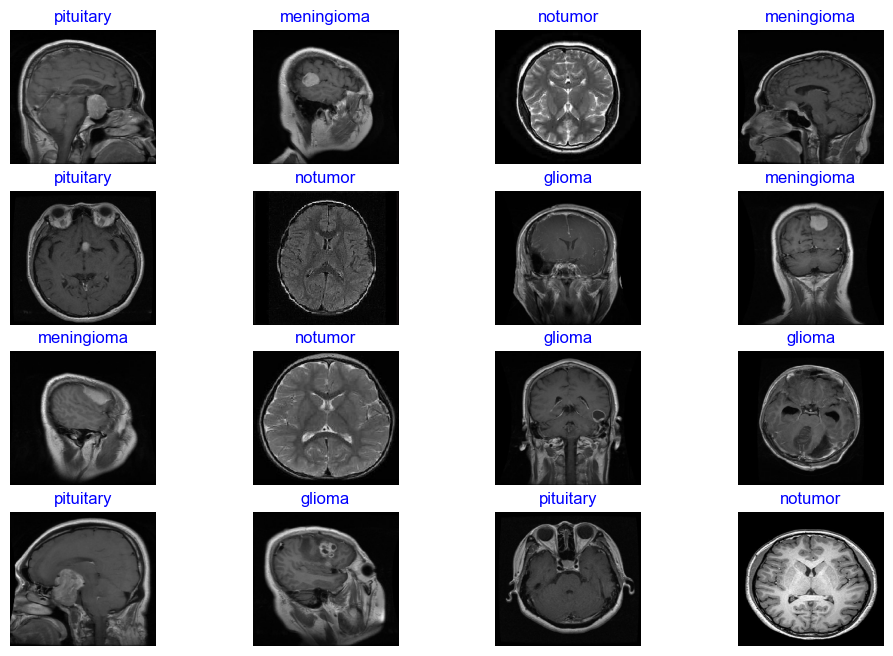

In [6]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images , labels = next(train_gen)

plt.figure(figsize = (12 , 8))

for i in range(16):
    plt.subplot(4 , 4 , i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    class_name = classes[index]
    plt.title (class_name , color = 'blue', fontsize = 12)
    plt.axis('off')
plt.show()

In [7]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [8]:
Epochs = 10

history = model.fit(
    train_gen,
    epochs = Epochs,
    verbose=1,
    validation_data = valid_gen,
    shuffle=True
)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.4210 - loss: 7.5782 - val_accuracy: 0.3664 - val_loss: 5.5547
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 540s 2s/step - accuracy: 0.3575 - loss: 4.5927 - val_accuracy: 0.4076 - val_loss: 3.6839
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 515s 1s/step - accuracy: 0.5105 - loss: 3.0722 - val_accuracy: 0.5328 - val_loss: 2.4773
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 586s 2s/step - accuracy: 0.5371 - loss: 2.1342 - val_accuracy: 0.5359 - val_loss: 1.7796
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 571s 2s/step - accuracy: 0.6555 - loss: 1.6078 - val_accuracy: 0.7435 - val_loss: 1.3710
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 522s 1s/step - accuracy: 0.7036 - loss: 1.3156 - val_accuracy: 0.7664 - val_loss: 1.1069
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.7227 - loss: 1.1066 - val_accuracy: 0.7740 - val_loss: 0.9372
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 659s 2s/step - accuracy: 0.7176 - loss: 1.0119 - val_accu

In [10]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 17s 348ms/step


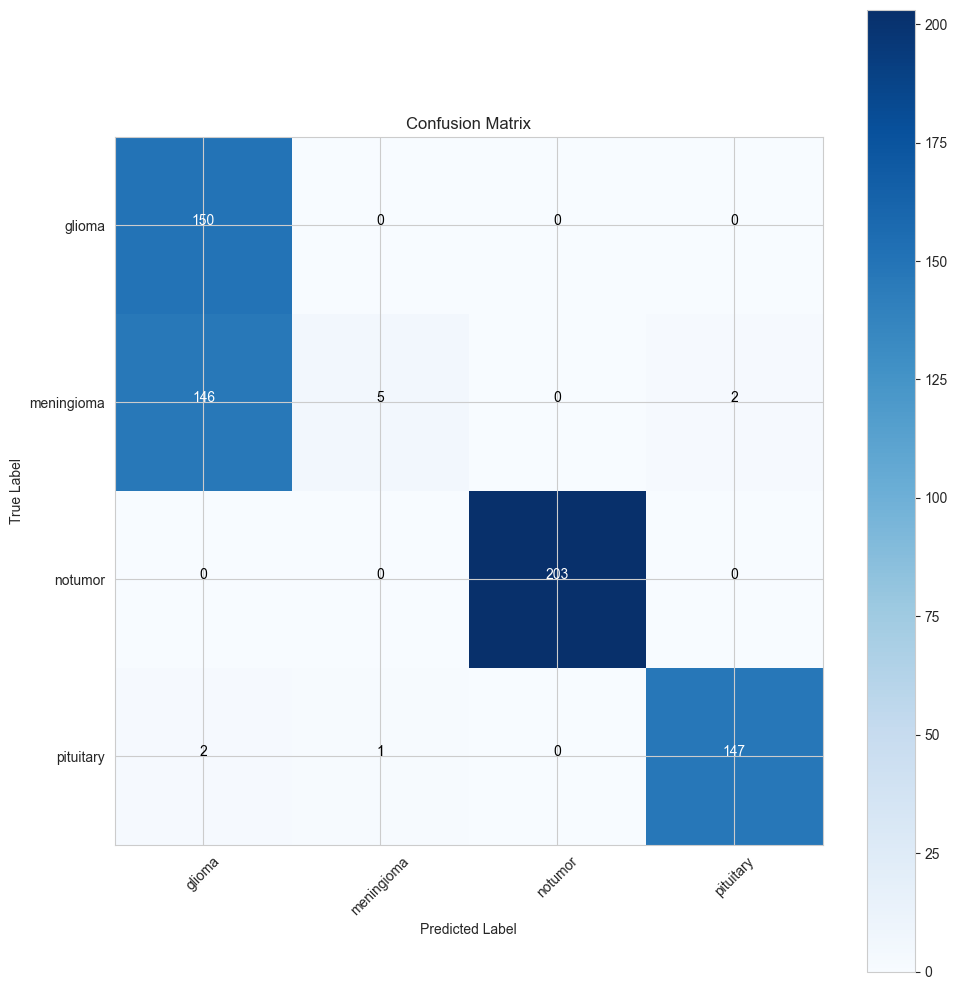

In [11]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [12]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       0.50      1.00      0.67       150
  meningioma       0.83      0.03      0.06       153
     notumor       1.00      1.00      1.00       203
   pituitary       0.99      0.98      0.98       150

    accuracy                           0.77       656
   macro avg       0.83      0.75      0.68       656
weighted avg       0.84      0.77      0.70       656



In [13]:
model.save("model.h5")

In [14]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

In [15]:
model = load_model('model.h5', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [18]:
gambar = tf.keras.preprocessing.image.load_img('./dataset/dataset/Testing/glioma/Te-glTr_0000.jpg', target_size=img_size)

In [19]:
input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

In [20]:
input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [21]:
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [22]:
print(predicted_class)

[0]


In [23]:
names = [classes[i] for i in predicted_class]
print(names)

['glioma']
